# 종합 실습 3 - 회귀

이번 실습에서는 `California Housing` 데이터셋을 사용하여
회귀 문제를 전체 흐름으로 연결해본다.

이 데이터셋은 지역의 여러 수치형 정보로부터
주택 가격과 관련된 연속형 값을 예측하는 문제이다.

- 사용 개념
  - 입력과 target 정규화
  - 회귀용 MLP 구성
  - 손실 함수와 optimizer 설정
  - scheduler 적용
  - validation 기반 early stopping
  - MAE, RMSE, R² 해석
  - 실제값과 예측값 비교

분류와 달리 회귀는 정답 클래스 번호를 맞히는 것이 아니라
연속형 숫자 값을 예측한다는 점이 가장 큰 차이이다.

In [1]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. 데이터 확인

`California Housing` 데이터셋은 캘리포니아 지역의 여러 통계 정보를 바탕으로
주택 가격과 관련된 연속형 값을 예측하는 회귀 데이터셋이다.

여기서 target은 클래스가 아니라 숫자이므로
이 문제는 분류가 아니라 회귀이다.

참고
- 입력 feature 수: 8개
- target: 주택 가격 관련 연속형 값
- sklearn에서는 target 값이 보통 10만 달러 단위로 정리되어 있다.

In [3]:
# data = fetch_california_housing()
# X = data.data
# y = data.target

california_housing_df = pd.read_csv('data/california_housing.csv')
X = california_housing_df.drop(columns=['MedHouseVal']).values
y = california_housing_df['MedHouseVal'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
# print('feature names:', data.feature_names)
print('target example:', y[:10])
print('target min/max:', y.min(), y.max())

X shape: (20640, 8)
y shape: (20640,)
target example: [4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]
target min/max: 0.14999 5.00001


## 2. train / validation / test 분리

데이터를 세 부분으로 나눈다.

- train: 모델 학습
- validation: 하이퍼파라미터와 epoch 흐름 확인
- test: 최종 성능 평가

회귀 문제도 분류와 마찬가지로 test 데이터는 마지막 평가 전까지 건드리지 않는 것이 중요하다.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

print('train:', X_train.shape, y_train.shape)
print('val  :', X_val.shape, y_val.shape)
print('test :', X_test.shape, y_test.shape)

train: (14448, 8) (14448,)
val  : (3096, 8) (3096,)
test : (3096, 8) (3096,)


## 3. 입력과 target 정규화

회귀에서는 입력뿐 아니라 target도 정규화하면
학습이 더 안정적으로 되는 경우가 많다.

주의할 점
- scaler의 `fit`은 train 데이터에만 한다.
- validation / test에는 train에서 학습한 scaler로 `transform`만 한다.

예측 후 최종 해석을 할 때는
target을 다시 원래 스케일로 되돌려야 한다.

In [5]:
# TODO 1. 입력과 target을 각각 정규화
# - x_scaler와 y_scaler를 따로 만든다.
# - fit은 train에만 한다.
# - y는 reshape(-1, 1) 후 정규화하고 다시 1차원으로 펴준다.

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).reshape(-1)
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).reshape(-1)
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).reshape(-1)

print('X_train_scaled mean (first 3 features):', X_train_scaled[:, :3].mean(axis=0))
print('y_train_scaled mean:', y_train_scaled.mean())
print('y_train_scaled std :', y_train_scaled.std())

X_train_scaled mean (first 3 features): [-2.19488049e-15 -1.65826501e-17  1.83803846e-15]
y_train_scaled mean: -1.5245587492084098e-16
y_train_scaled std : 1.0


## 4. Tensor / DataLoader 준비

회귀 문제에서는 정답 y도 연속형 값이므로
`float32` 형태로 두는 것이 일반적이다.

또한 출력층에서 값 하나를 예측할 것이므로
y의 shape도 `(batch_size, 1)` 형태로 맞춰준다.

In [6]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

xb, yb = next(iter(train_loader))
print('mini batch X shape:', xb.shape)
print('mini batch y shape:', yb.shape)
print('y example:', yb[:5].view(-1))


mini batch X shape: torch.Size([256, 8])
mini batch y shape: torch.Size([256, 1])
y example: tensor([-0.4892,  0.5450, -0.4711, -0.1704,  2.3455])


## 5. 회귀용 MLP 모델

출력층은 회귀용이므로 마지막에 뉴런 1개를 둔다.
분류 문제처럼 sigmoid나 softmax를 붙이지 않는다.

이번 실습에서는 지금까지 배운 내용을 바탕으로
- He 초기화
- ReLU
- Dropout
을 사용한 기본 MLP를 구성한다.

In [7]:
class HousingMLP(nn.Module):
    def __init__(self, input_dim=8, hidden_dims=[128, 64], dropout_rate=0.1):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
    
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x)

model = HousingMLP()
print(model)

HousingMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 6. 학습/평가 함수

회귀에서는 보통 다음 지표들을 함께 본다.

- MAE: 평균 절대 오차
- RMSE: 제곱 오차에 더 민감한 지표
- R²: 예측이 데이터 변동을 얼마나 설명하는지 보는 지표

학습 중 손실 계산은 정규화된 target 기준으로 진행하고,
최종 해석용 지표는 원래 스케일로 복원한 뒤 계산한다.

In [8]:
def train_one_epoch_regression(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate_regression(model, loader, criterion, y_scaler):
    model.eval()

    total_loss = 0.0
    preds_scaled = []
    targets_scaled = []

    with torch.no_grad():
        for X_batch, y_batch in loader:

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds_scaled.append(pred.numpy())
            targets_scaled.append(y_batch.numpy())

    avg_loss = total_loss / len(loader.dataset)

    preds_scaled = np.vstack(preds_scaled)
    targets_scaled = np.vstack(targets_scaled)

    # TODO 2. 정규화된 예측값과 정답을 원래 스케일로 되돌려 회귀 지표를 계산한다.
    
    preds = y_scaler.inverse_transform(preds_scaled).reshape(-1)
    targets = y_scaler.inverse_transform(targets_scaled).reshape(-1)

    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2 = r2_score(targets, preds)

    return avg_loss, mae, rmse, r2, targets, preds


## 7. optimizer와 scheduler 설정

이번 회귀 실습에서는 다음 구성을 사용한다.

- loss: MSELoss
- optimizer: AdamW
- scheduler: CosineAnnealingLR

초반에는 비교적 크게 학습하고,
후반에는 learning rate를 점차 줄이면서 안정적으로 수렴하도록 한다.

In [9]:
# TODO 3. 손실 함수, optimizer, scheduler를 설정
# - 손실 함수: MSELoss
# - optimizer: AdamW, lr=0.001, weight_decay=1e-4
# - scheduler: CosineAnnealingLR(T_max=80, eta_min=1e-5)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-5)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## 8. 전체 학습 루프 + Early Stopping

validation loss가 더 이상 좋아지지 않으면
학습을 멈추고 가장 좋았던 모델을 저장한다.

회귀에서도 마지막 epoch 모델보다
validation 기준 best model을 쓰는 것이 중요하다.

In [10]:
num_epochs = 100
early_stopping_patience = 15

history = {
    'train_loss': [],
    'val_loss': [],
    'val_mae': [],
    'val_rmse': [],
    'val_r2': [],
    'lr': []
}

best_val_loss = float('inf')
best_epoch = 0
best_state = None
patience_counter = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch_regression(model, train_loader, criterion, optimizer)
    val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate_regression(model, val_loader, criterion, y_scaler)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f'Epoch {epoch+1:03d} | '
            f'train_loss={train_loss:.4f} | '
            f'val_loss={val_loss:.4f} | '
            f'val_mae={val_mae:.4f} | '
            f'val_rmse={val_rmse:.4f} | '
            f'val_r2={val_r2:.4f} | '
            f'lr={optimizer.param_groups[0]["lr"]:.6f}'
        )

    if patience_counter >= early_stopping_patience:
        print(f'early stopping at epoch {epoch+1}')
        break

print('best epoch:', best_epoch)
print('best val loss:', round(best_val_loss, 4))


Epoch 001 | train_loss=0.8433 | val_loss=0.4080 | val_mae=0.5376 | val_rmse=0.7394 | val_r2=0.5804 | lr=0.001000
Epoch 010 | train_loss=0.3679 | val_loss=0.3184 | val_mae=0.4612 | val_rmse=0.6531 | val_r2=0.6725 | lr=0.000962
Epoch 020 | train_loss=0.3067 | val_loss=0.2905 | val_mae=0.4445 | val_rmse=0.6239 | val_r2=0.7012 | lr=0.000855
Epoch 030 | train_loss=0.2905 | val_loss=0.2657 | val_mae=0.4154 | val_rmse=0.5967 | val_r2=0.7267 | lr=0.000694
Epoch 040 | train_loss=0.2679 | val_loss=0.2564 | val_mae=0.4075 | val_rmse=0.5861 | val_r2=0.7363 | lr=0.000505
Epoch 050 | train_loss=0.2614 | val_loss=0.2556 | val_mae=0.4040 | val_rmse=0.5851 | val_r2=0.7372 | lr=0.000316
Epoch 060 | train_loss=0.2510 | val_loss=0.2474 | val_mae=0.3985 | val_rmse=0.5757 | val_r2=0.7456 | lr=0.000155
Epoch 070 | train_loss=0.2505 | val_loss=0.2480 | val_mae=0.3989 | val_rmse=0.5765 | val_r2=0.7449 | lr=0.000048
early stopping at epoch 77
best epoch: 62
best val loss: 0.2468


## 9. 학습 곡선 확인

train loss와 validation loss를 함께 보면서
학습이 안정적으로 진행되었는지 확인한다.

회귀에서는 loss만 보지 말고,
뒤에서 MAE, RMSE, R²도 같이 확인하는 것이 좋다.

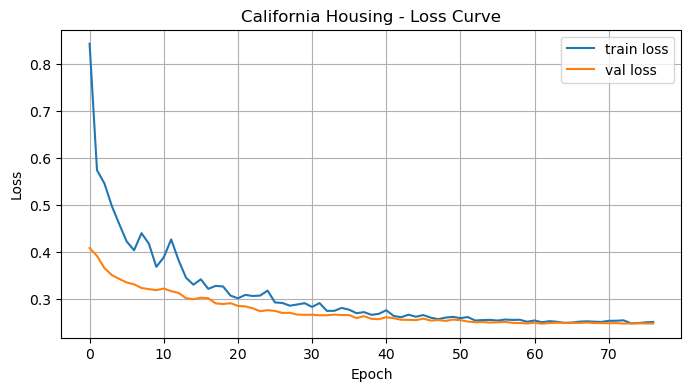

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.title('California Housing - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 10. best model 복원 후 test 평가

이제 validation 기준으로 가장 좋았던 모델을 복원하고
test 데이터에서 최종 성능을 평가한다.

In [12]:
# TODO 4. best_state를 다시 불러오고 test 성능을 평가

model.load_state_dict(best_state)

test_loss, test_mae, test_rmse, test_r2, y_true_test, y_pred_test = evaluate_regression(
    model, test_loader, criterion, y_scaler
)

print('---')
print('test metrics')
print(f'- loss: {test_loss:.4f}')
print(f'- mae: {test_mae:.4f}')
print(f'- rmse: {test_rmse:.4f}')
print(f'- r2: {test_r2:.4f}')

---
test metrics
- loss: 0.2157
- mae: 0.3825
- rmse: 0.5375
- r2: 0.7815


## 11. Validation 지표 곡선 확인

회귀에서는 validation loss 외에도
MAE, RMSE, R² 흐름을 같이 보면 해석이 훨씬 쉬워진다.

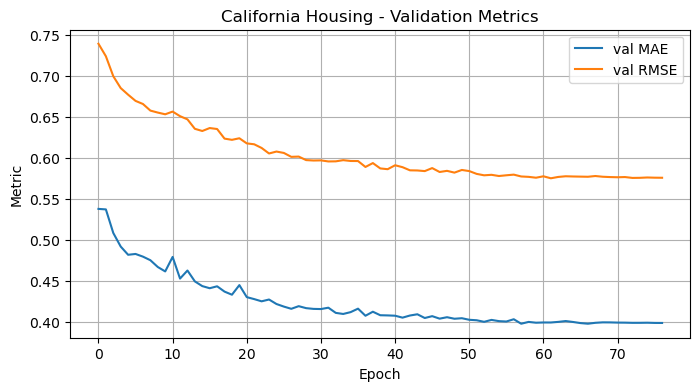

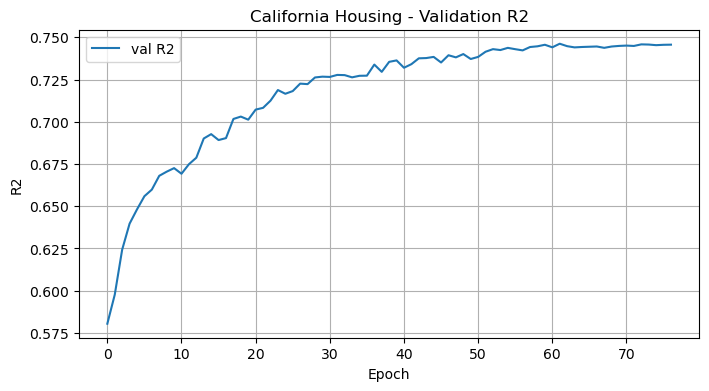

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history['val_mae'], label='val MAE')
plt.plot(history['val_rmse'], label='val RMSE')
plt.title('California Housing - Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history['val_r2'], label='val R2')
plt.title('California Housing - Validation R2')
plt.xlabel('Epoch')
plt.ylabel('R2')
plt.legend()
plt.grid(True)
plt.show()

## 12. learning rate 변화 확인

CosineAnnealingLR을 사용했으므로
learning rate가 점점 부드럽게 감소하는 모습을 볼 수 있다.

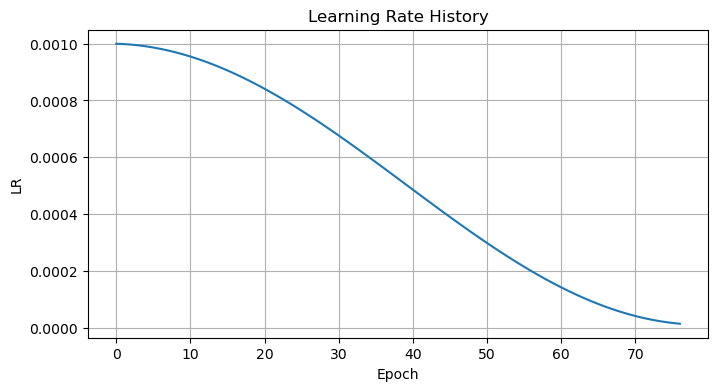

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history['lr'])
plt.title('Learning Rate History')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.grid(True)
plt.show()

## 13. 실제값 vs 예측값 시각화

산점도에서 점들이 대각선에 가까울수록
예측이 실제값과 비슷하다는 뜻이다.

완벽한 모델이라면 모든 점이 대각선 위에 놓이게 된다.

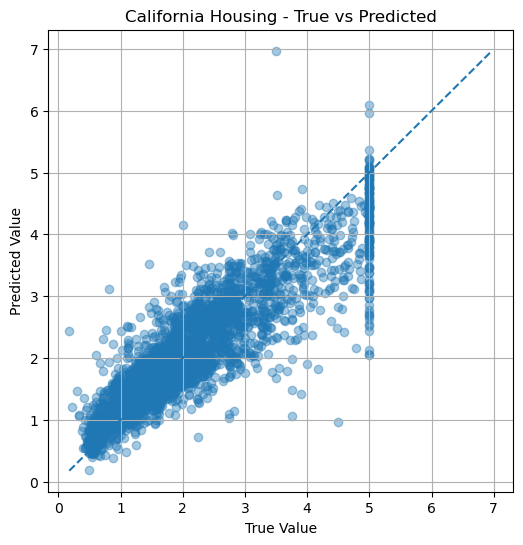

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true_test, y_pred_test, alpha=0.4)

min_val = min(y_true_test.min(), y_pred_test.min())
max_val = max(y_true_test.max(), y_pred_test.max())

plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.title('California Housing - True vs Predicted')
plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.grid(True)
plt.show()

## 14. 잔차(residual) 확인

잔차는 `실제값 - 예측값`이다.

잔차가 0 근처에 고르게 퍼져 있으면 좋고,
특정 구간에서 한쪽으로 치우친 패턴이 강하면
아직 잘 못 맞추는 영역이 있다는 뜻이다.

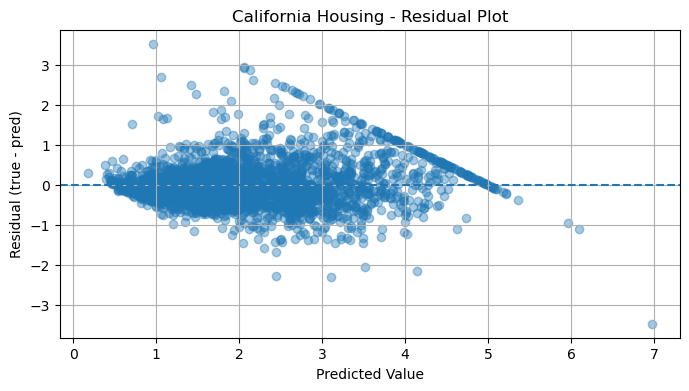

In [16]:
# TODO 5. residual을 계산하고 residual plot을 그려본다.

residuals = y_true_test - y_pred_test

plt.figure(figsize=(8, 4))
plt.scatter(y_pred_test, residuals, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.title('California Housing - Residual Plot')
plt.xlabel('Predicted Value')
plt.ylabel('Residual (true - pred)')
plt.grid()
plt.show()

## 15. 몇 개 샘플 직접 보기

회귀는 분류처럼 정답/오답으로 끝나는 것이 아니라
각 샘플마다 오차 크기를 함께 보는 것이 중요하다.

In [17]:
for i in range(min(10, len(y_true_test))):
    print(
        f'index={i:2d} | '
        f'true={y_true_test[i]:7.3f} | '
        f'pred={y_pred_test[i]:7.3f} | '
        f'error={y_true_test[i] - y_pred_test[i]:7.3f}'
    )

index= 0 | true=  1.000 | pred=  0.967 | error=  0.033
index= 1 | true=  1.188 | pred=  1.144 | error=  0.044
index= 2 | true=  3.761 | pred=  3.017 | error=  0.744
index= 3 | true=  2.000 | pred=  1.335 | error=  0.665
index= 4 | true=  0.952 | pred=  1.836 | error= -0.884
index= 5 | true=  1.285 | pred=  1.185 | error=  0.100
index= 6 | true=  2.613 | pred=  2.362 | error=  0.251
index= 7 | true=  1.794 | pred=  2.011 | error= -0.217
index= 8 | true=  4.070 | pred=  4.255 | error= -0.185
index= 9 | true=  1.750 | pred=  1.747 | error=  0.003
